In [1]:
import os
import numpy as np
import torch
import nibabel as nib
import pandas as pd
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
import matplotlib.pyplot as plt
import re 

In [2]:


def load_nifti(path):
    return nib.load(path).get_fdata().astype(np.float32)

def normalize(img):
    img = img - np.min(img)
    if np.max(img) > 0:
        img = img / np.max(img)
    return img

def compute_3d_metrics(real, fake):
    real = normalize(real)
    fake = normalize(fake)

    ssim_val = ssim(real, fake, data_range=1.0)
    psnr_val = psnr(real, fake, data_range=1.0)
    mae = np.mean(np.abs(real - fake))
    mse = np.mean((real - fake) ** 2)

    return {
        'SSIM': round(ssim_val, 4),
        'PSNR': round(psnr_val, 2),
        'MAE': round(mae, 5),
        'MSE': round(mse, 5)
    }

def save_metrics_to_excel(results, output_path='similarity_metrics.xlsx'):
    df = pd.DataFrame.from_dict(results, orient='index')
    df.index.name = 'Sample ID'
    df.reset_index(inplace=True)
    df.to_excel(output_path, index=False)
    print(f"\n✅ Saved metrics to Excel: {output_path}")
    return df  # return the dataframe for plotting

def plot_metric_trends(df):
    x = range(len(df))
    metrics = ['SSIM', 'PSNR', 'MAE', 'MSE']

    plt.figure(figsize=(16, 12))
    for i, metric in enumerate(metrics, 1):
        plt.subplot(2, 2, i)
        plt.plot(x, df[metric], marker='o')
        plt.title(f'{metric} over Samples')
        plt.xlabel('Sample Index (from fake_dir order)')
        plt.ylabel(metric)
        plt.grid(True)

    plt.tight_layout()
    plt.savefig('model_3/test_metric_trends.png')
    plt.show()
    print("📊 Plots saved as 'metric_trends.png'")




In [3]:
def center_crop_to_match(larger, target_shape):
    """
    Center crop a 3D volume to the shape of a smaller target volume.
    """
    crop = []
    for dim_l, dim_t in zip(larger.shape, target_shape):
        start = (dim_l - dim_t) // 2
        crop.append(slice(start, start + dim_t))
    return larger[tuple(crop)]

In [4]:
def get_files_by_creation_order(directory, extensions=('.nii', '.nii.gz')):
    files = [
        f for f in os.listdir(directory)
        if f.endswith(extensions)
    ]
    # Sort by creation time (earliest first)
    files.sort(key=lambda x: os.path.getctime(os.path.join(directory, x)))
    return files

In [5]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm

def load_nifti(path):
    return nib.load(path).get_fdata()

def evaluate_all(fake_dir, real_dir):
    results = {}
    fake_files = sorted([f for f in os.listdir(fake_dir) if f.endswith('.nii')])

    for fake_file in tqdm(fake_files, desc="Evaluating"):
        index = os.path.splitext(fake_file)[0]
        real_file = f"test-volume-{index}.nii"
        fake_path = os.path.join(fake_dir, fake_file)
        real_path = os.path.join(real_dir, real_file)

        print(f"Comparing fake: {fake_file}  <-->  real: {real_file}")

        if not os.path.exists(real_path):
            print(f"⚠️ Real file not found for {fake_file}")
            continue

        try:
            fake_img = load_nifti(fake_path)
            real_img = load_nifti(real_path)

            # Crop only the larger volume
            if fake_img.shape != real_img.shape:
                if all(f <= r for f, r in zip(fake_img.shape, real_img.shape)):
                    real_img = center_crop_to_match(real_img, fake_img.shape)
                elif all(r <= f for f, r in zip(fake_img.shape, real_img.shape)):
                    fake_img = center_crop_to_match(fake_img, real_img.shape)
                else:
                    print(f"❌ Error: mismatched axes, can't crop {fake_file}")
                    continue

            metrics = compute_3d_metrics(real_img, fake_img)
            results[fake_file] = metrics

        except Exception as e:
            print(f"❌ Error processing {fake_file}: {e}")

    return results

Evaluating:   0%|                                                                      | 0/70 [00:00<?, ?it/s]

Comparing fake: 0.nii  <-->  real: test-volume-0.nii


Evaluating:   1%|▉                                                             | 1/70 [00:03<03:58,  3.46s/it]

Comparing fake: 1.nii  <-->  real: test-volume-1.nii


Evaluating:   3%|█▊                                                            | 2/70 [00:06<03:50,  3.39s/it]

...

Comparing fake: 8.nii  <-->  real: test-volume-8.nii


Evaluating:  99%|████████████████████████████████████████████████████████████▏| 69/70 [03:49<00:03,  3.33s/it]

Comparing fake: 9.nii  <-->  real: test-volume-9.nii


Evaluating: 100%|█████████████████████████████████████████████████████████████| 70/70 [03:53<00:00,  3.33s/it]



✅ Saved metrics to Excel: model6/_testsimilarity_metrics.xlsx


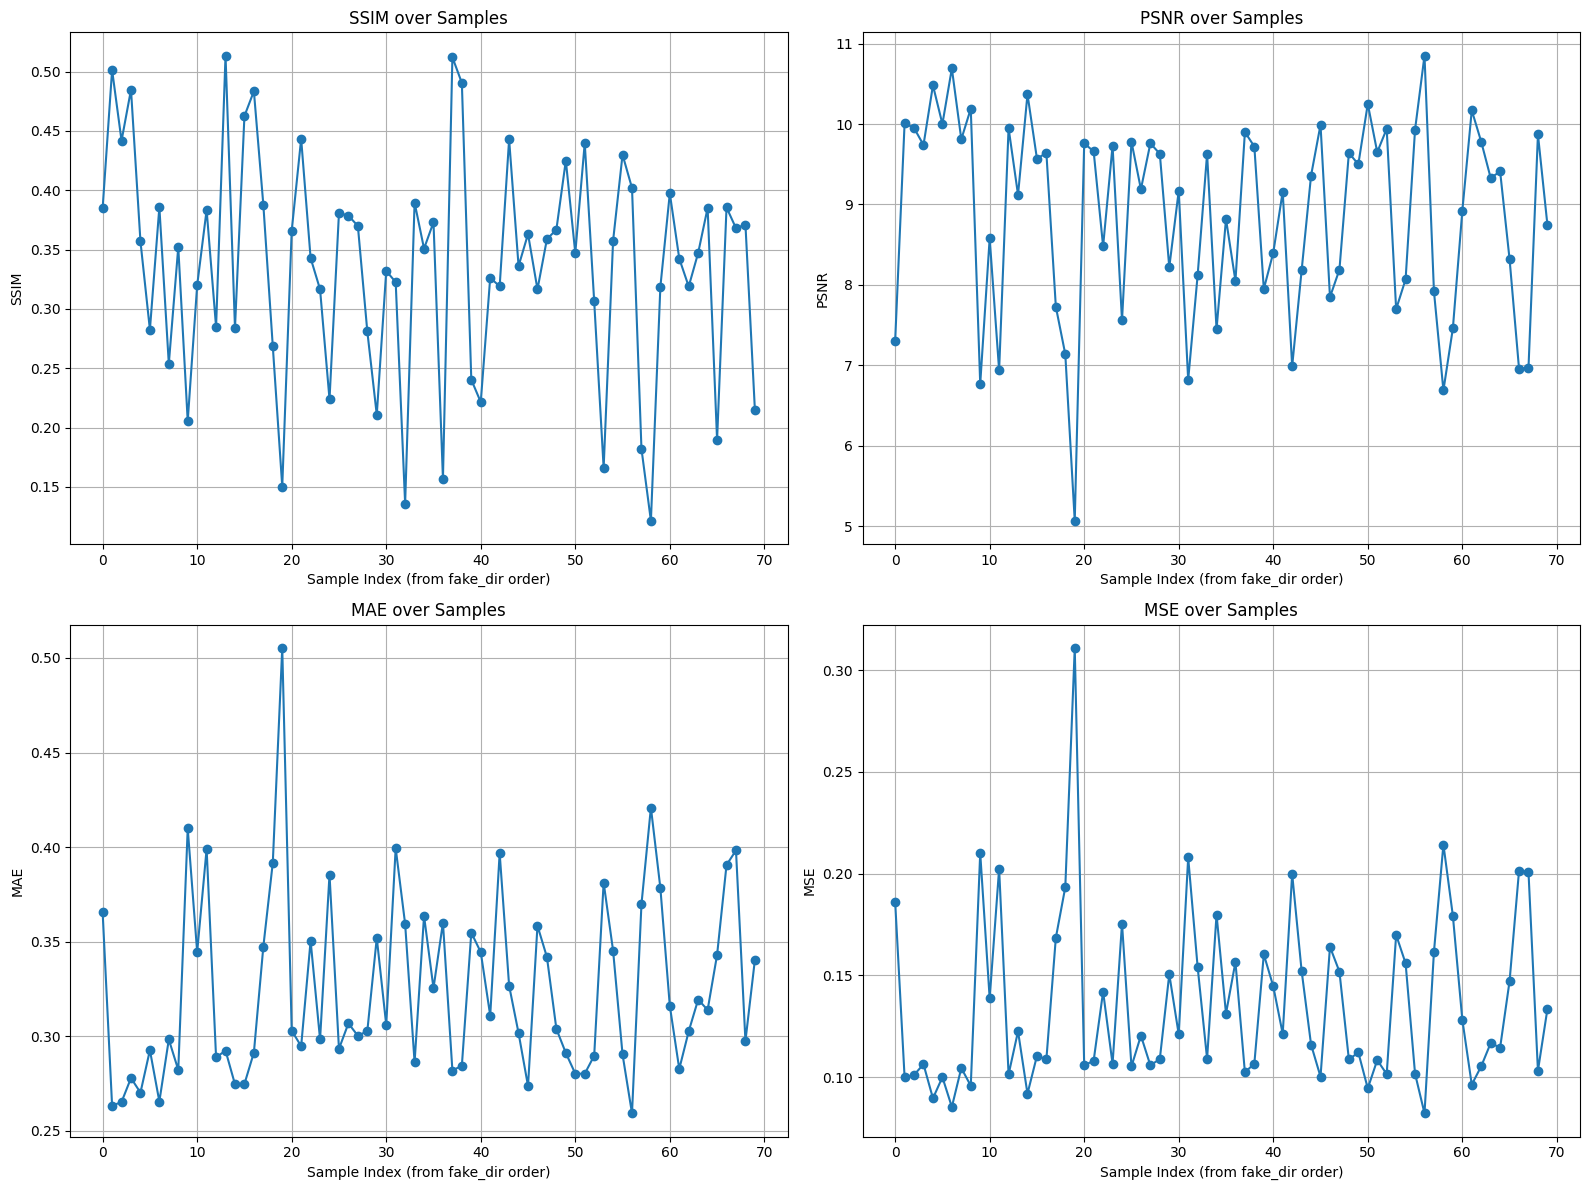

📊 Plots saved as 'metric_trends.png'


In [6]:
if __name__ == "__main__":
    fake_dir = 'model6/Generated_Test_CT'
    real_dir = '../dataset/TESTCTALIGNED'
    output_excel = 'model6/_testsimilarity_metrics.xlsx'
    
    results = evaluate_all(fake_dir,real_dir)
    df = save_metrics_to_excel(results,output_excel)
    plot_metric_trends(df)